In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Step 2: Load Dataset
df = pd.read_csv("Salary_dataset.csv")


In [3]:
# Step 3: Display First 5 Rows
print(df.head())

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [4]:
# Step 4: Check Missing Values
print(df.isnull().sum())

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


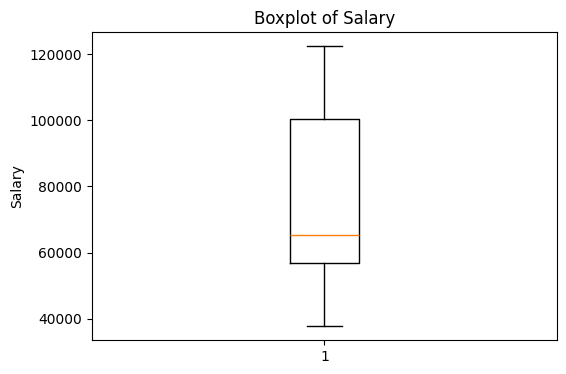

In [15]:
# STEP 5: OUTLIER ANALYSIS
# Boxplot for detecting outliers
plt.figure(figsize=(6,4))
plt.boxplot(df["Salary"])
plt.title("Boxplot of Salary")
plt.ylabel("Salary")
plt.show()

In [16]:
# Using IQR Method
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)



Lower Bound: -9014.25
Upper Bound: 166281.75


In [5]:
# Step 5: Define Features and Target
X = df[["YearsExperience"]]
y = df["Salary"]

In [6]:
# Step 6: Split Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [7]:
# Step 7: Create Model
model = LinearRegression()

In [8]:
# Step 8: Train Model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# Step 9: Predict on Test Data
y_pred = model.predict(X_test)
print("\nPredictions:")
print(y_pred)


Predictions:
[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]


In [11]:
# Step 10: Model Coefficients
print("\nSlope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)


Slope (Coefficient): 9423.81532303098
Intercept: 24380.20147947369


In [12]:
# Step 12: Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Absolute Error:", mae)
print("R2 Score:", r2)



Mean Absolute Error: 6286.453830757745
R2 Score: 0.9024461774180498


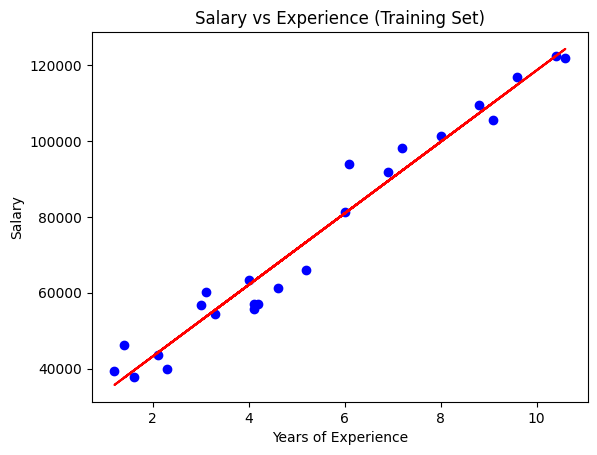

In [13]:
# Step 13: Visualization

# Training Data Plot
plt.scatter(X_train, y_train, color="blue")
plt.plot(X_train, model.predict(X_train), color="red")
plt.title("Salary vs Experience (Training Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

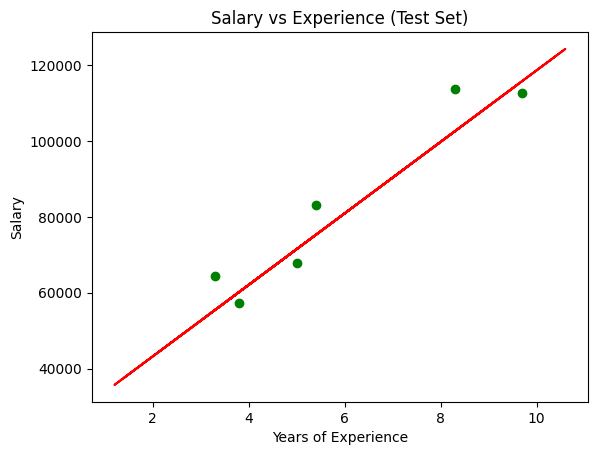

In [14]:
# Test Data Plot
plt.scatter(X_test, y_test, color="green")
plt.plot(X_train, model.predict(X_train), color="red")
plt.title("Salary vs Experience (Test Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [17]:
import joblib

# Save trained model
joblib.dump(model, "salary_model.pkl")

print("Model saved successfully")

Model saved successfully
